# CNM Analysis for d+Au RHIC (200 GeV)
This notebook calculates and plots the coherent nuclear matter (CNM) effects for charmonia in d+Au collisions at 200 GeV.

**Components:**
- **nPDF**: Shadowing using EPPS21
- **ELoss**: Coherent energy loss (Arleo-Peigné)
- **Broad**: Cronin pT broadening
- **ELoss + Broad**: Product of ELoss and Broadening factors
- **Total CNM**: nPDF × (ELoss × Broad)

**Styling**: Publication-ready plots with consistent color schemes.

## Setup & Calc

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import replace

# Add paths for custom modules
sys.path.append('..')
sys.path.append('../eloss_code')
sys.path.append('../cnm_combine')
sys.path.append('../npdf_code')

from cnm_combine_fast import CNMCombineFast
from particle import Particle
from system_configs import RHICConfig as Config

import warnings
warnings.filterwarnings('ignore')

# Constants and Knobs
SAVE_PDF = True
SAVE_CSV = True
DPI = 150
ALPHA_BAND = 0.25
STEP_DEFAULT = True

# Color Scheme
COLORS = {
    'npdf': '#E69F00',
    'eloss': "#EC5B5B",
    'broad': "#2B2BEF",
    'eloss_broad': "#020202", # Product of loss and broad
    'cnm': 'gray'
}

COMP_LABELS = {
    'npdf': 'nPDF (EPPS21)',
    'eloss': 'Energy Loss',
    'broad': r'$p_T$ Broadening',
    'eloss_broad': r'ELoss + $p_T$ Broad',
    'cnm': 'Total CNM'
}

print("Setup complete.")

Setup complete.


In [2]:
def step_from_centers(xc, yc):
    xc = np.asarray(xc, float)
    yc = np.asarray(yc, float)
    if xc.size < 2:
        dx = 1.0
        return np.array([xc[0]-0.5*dx, xc[0]+0.5*dx], float), np.array([yc[0], yc[0]], float)
    dx = xc[1] - xc[0] 
    edges = np.concatenate([xc - 0.5*dx, [xc[-1] + 0.5*dx]])
    vals = np.concatenate([yc, [yc[-1]]])
    return edges, vals

def apply_pub_style(ax, xlim, ylim, xlabel, ylabel, tag=None, note=None):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.axhline(1.0, color='k', ls='-', lw=0.8, alpha=0.5)
    
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    
    if tag:
        ax.text(0.95, 0.95, tag, transform=ax.transAxes, ha='right', va='top', 
                fontsize=12, fontweight='bold')
    if note:
        ax.text(0.05, 0.05, note, transform=ax.transAxes, ha='left', va='bottom', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

def plot_component_band(ax, x_cent, bands, comp, tag, step=True):
    Rc_dict, Rlo_dict, Rhi_dict = bands[comp]
    xc = np.asarray(x_cent)
    yc = np.asarray(Rc_dict[tag])
    yl = np.asarray(Rlo_dict[tag])
    yh = np.asarray(Rhi_dict[tag])

    # Ensure lo <= hi always (fixes accidental swaps)
    yl2 = np.minimum(yl, yh)
    yh2 = np.maximum(yl, yh)

    # (Optional) if you want the band to always contain the central curve:
    yl2 = np.minimum(yl2, yc)
    yh2 = np.maximum(yh2, yc)
        
    color = COLORS.get(comp, 'black')
    label = COMP_LABELS.get(comp, comp)
    
    if step:
        xe, ye = step_from_centers(xc, yc)
        _, yel = step_from_centers(xc, yl2)
        _, yeh = step_from_centers(xc, yh2)
        ax.step(xe, ye, where='post', color=color, lw=1.7, label=label)
        ax.fill_between(xe, yel, yeh, step='post', color=color, alpha=ALPHA_BAND, lw=0)
    else:
        ax.plot(xc, yc, color=color, lw=1.7, label=label)
        ax.fill_between(xc, yl2, yh2, color=color, alpha=ALPHA_BAND, lw=0)

In [3]:
print("Processing RHIC 200 GeV...")
energy = 200
sqrts = 200.0
outdir = Path('../outputs/cnm_combined/RHIC_200GeV')
outdir.mkdir(parents=True, exist_ok=True)

particle = Particle(family='charmonia', state='avg')
cnm = CNMCombineFast.from_defaults(
    energy=str(energy),
    family='charmonia',
    particle_state='avg',
    alpha_s_mode='constant',
    alpha0=0.5,
    cent_bins=Config.cent_bins
)

components = ['npdf', 'eloss', 'broad', 'eloss_broad', 'cnm']

Processing RHIC 200 GeV...


## 1. $R_{dA}$ vs y (Integrated over pT [0, 2.5] GeV)

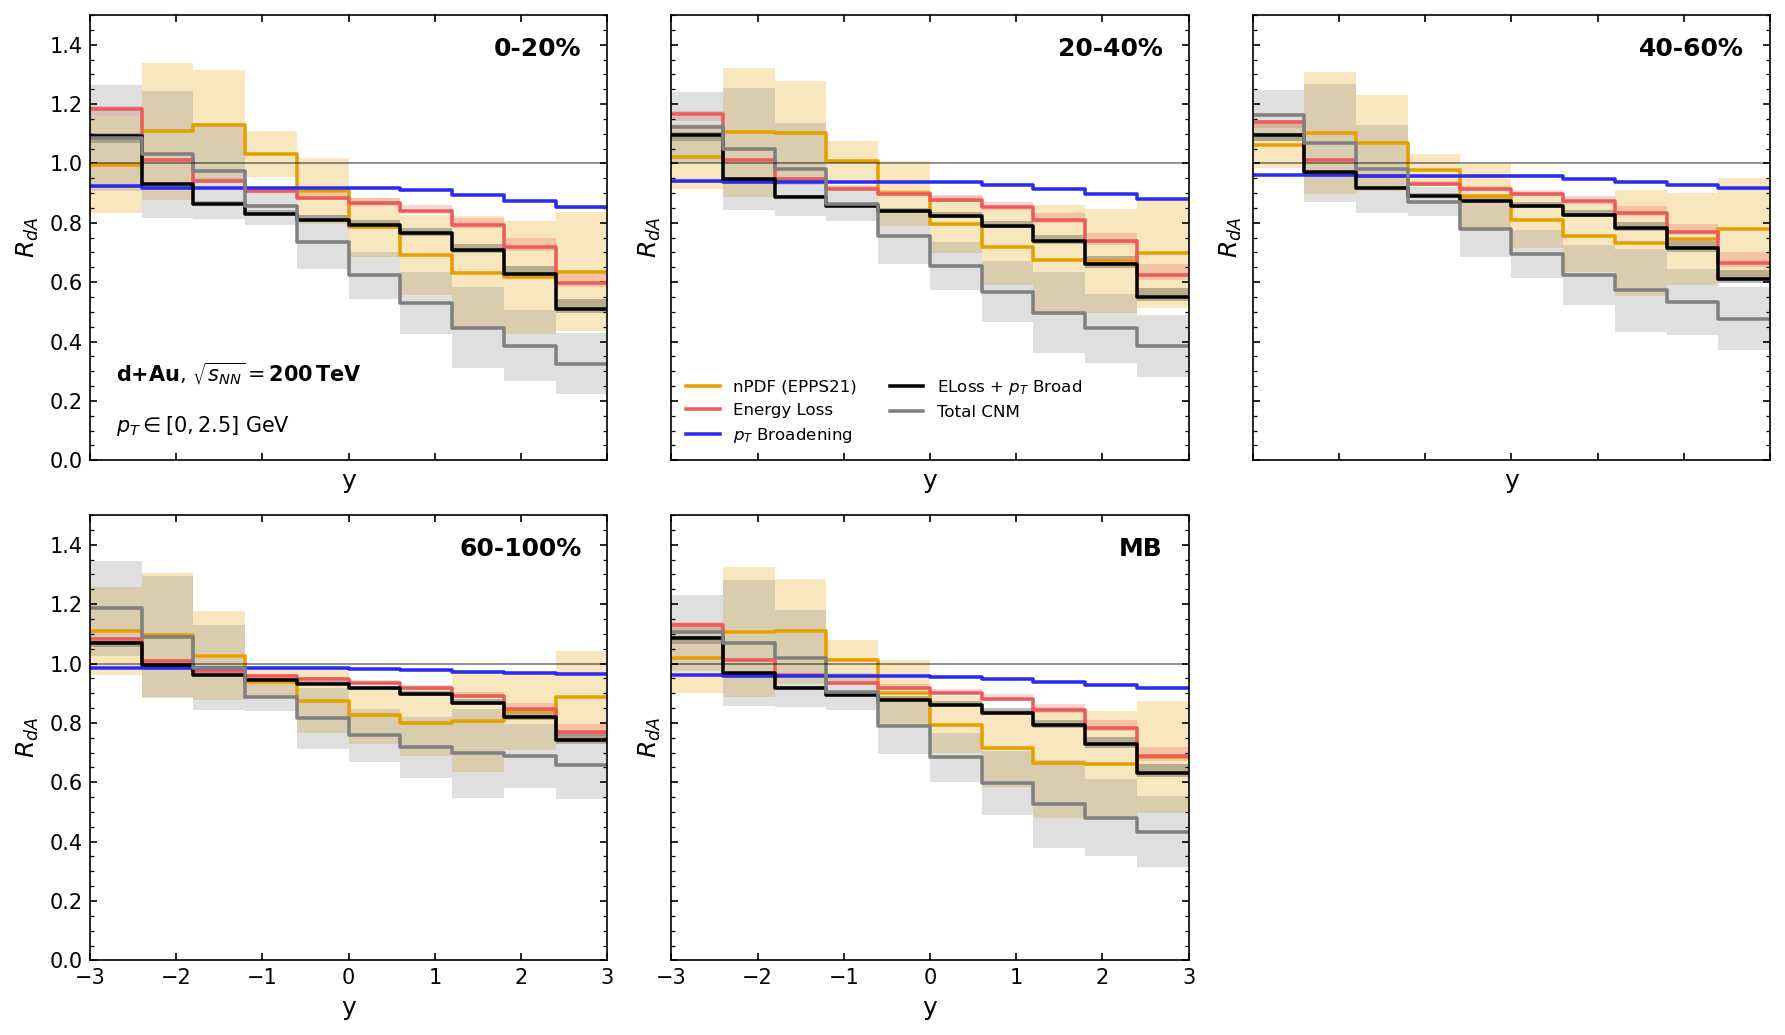

In [4]:
# 1. R_dA vs y (Integrated over pT [0, 2.5] GeV)
y_edges = np.linspace(-3.0, 3.0, 11)
y_cent, labels, final_bands_y = cnm.cnm_vs_y(
    y_edges, 
    pt_range_avg=(0.0, 2.5), 
    components=components,
    include_mb=True
)

tags_to_plot = labels + ['MB']
n_pan = len(tags_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_pan / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
note_y = rf"$\mathbf{{d{{+}}Au}}$, $\sqrt{{s_{{NN}}}} = \mathbf{{{energy}}}\,\mathbf{{TeV}}$" \
         + "\n\n" + r"$p_T \in [0,2.5]$ GeV"

for i, tag in enumerate(tags_to_plot):
    ax = axes[i]
    for comp in components: plot_component_band(ax, y_cent, final_bands_y, comp, tag)
    apply_pub_style(ax, (-3.0, 3.0), (0.0, 1.5), 'y', r'$R_{dA}$', tag=tag, note=note_y if i==0 else None)
    if i == 1: ax.legend(loc='lower left', fontsize=8, ncol=2, frameon=False)

for k in range(n_pan, len(axes)): fig.delaxes(axes[k])
fig.tight_layout()
if SAVE_PDF: fig.savefig(outdir / f'RdAu_vs_y_all_components_200GeV.pdf', bbox_inches='tight')
plt.show()

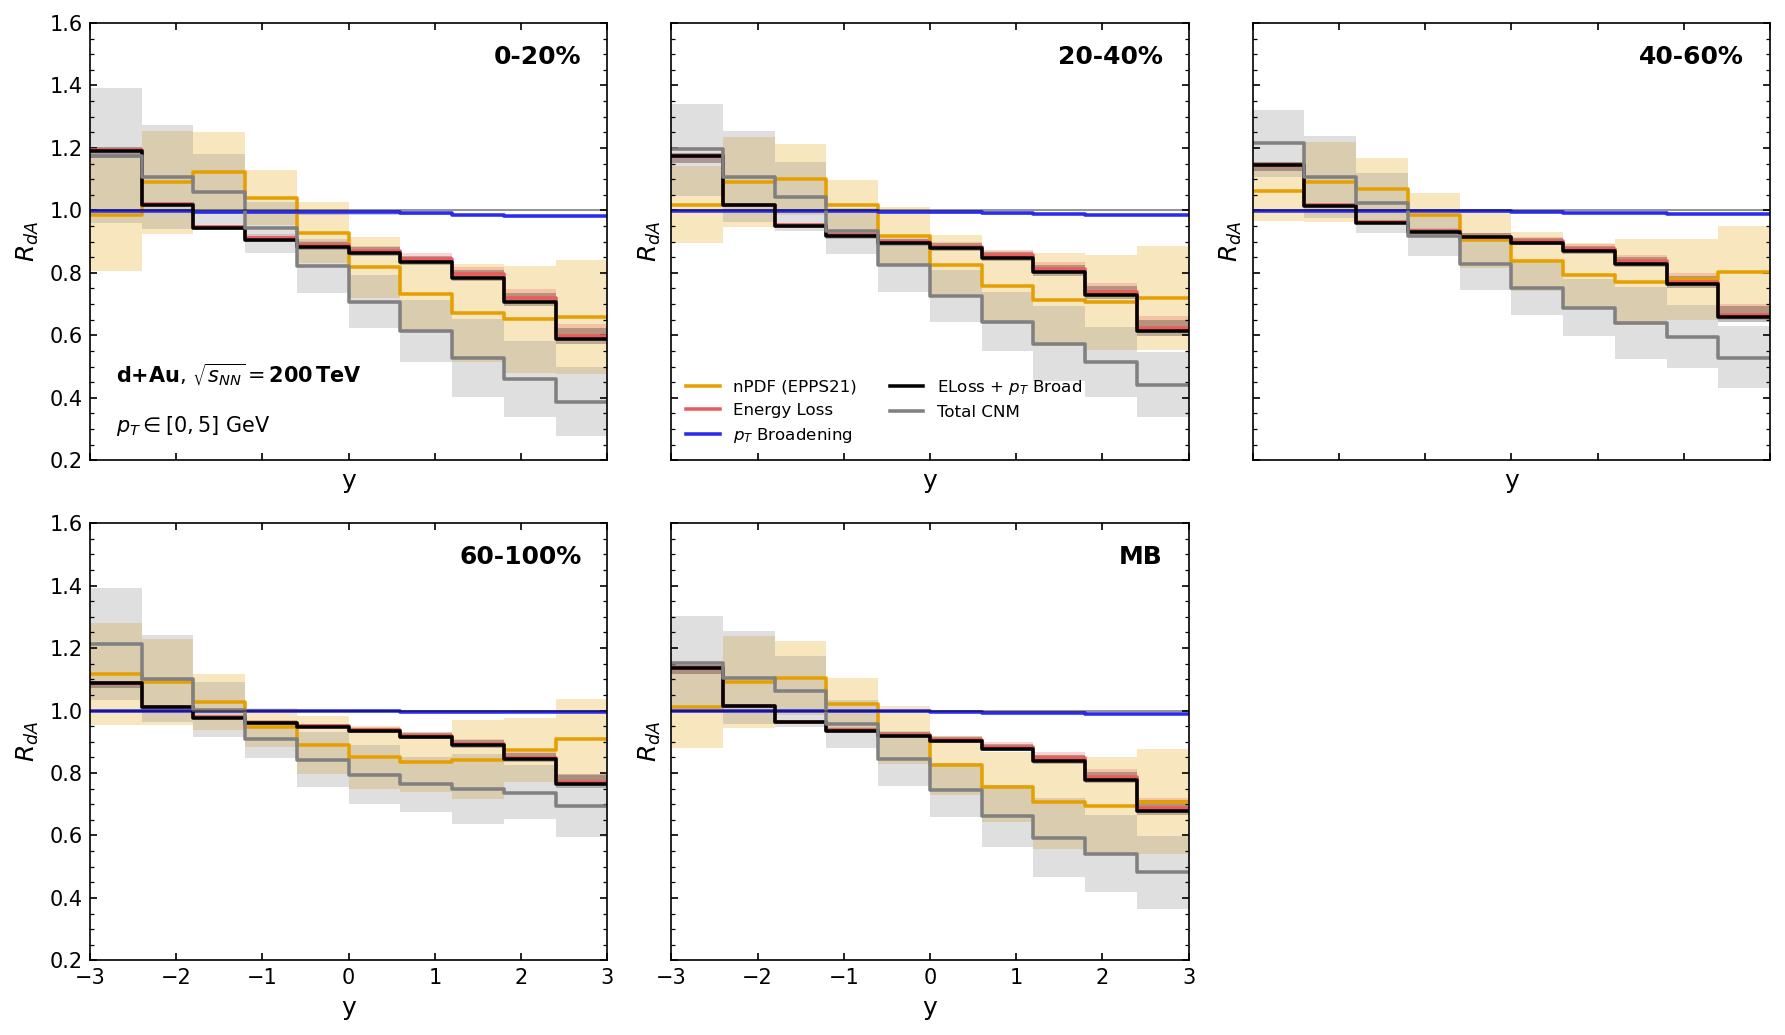

In [5]:
# 1. R_dA vs y (Integrated over pT [0, 5.0] GeV)
y_edges = np.linspace(-3.0, 3.0, 11)
y_cent, labels, final_bands_y = cnm.cnm_vs_y(
    y_edges, 
    pt_range_avg=(0.0, 5.0), 
    components=components,
    include_mb=True
)

tags_to_plot = labels + ['MB']
n_pan = len(tags_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_pan / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
note_y = rf"$\mathbf{{d{{+}}Au}}$, $\sqrt{{s_{{NN}}}} = \mathbf{{{energy}}}\,\mathbf{{TeV}}$" \
         + "\n\n" + r"$p_T \in [0,5]$ GeV"
for i, tag in enumerate(tags_to_plot):
    ax = axes[i]
    for comp in components: plot_component_band(ax, y_cent, final_bands_y, comp, tag)
    apply_pub_style(ax, (-3.0, 3.0), (0.2, 1.6), 'y', r'$R_{dA}$', tag=tag, note=note_y if i==0 else None)
    if i == 1: ax.legend(loc='lower left', fontsize=8, ncol=2, frameon=False)

for k in range(n_pan, len(axes)): fig.delaxes(axes[k])
fig.tight_layout()
if SAVE_PDF: fig.savefig(outdir / f'RdAu_vs_y_all_components_200GeV_wider.pdf', bbox_inches='tight')
plt.show()

## 2. $R_{dA}$ vs $p_T$ in Rapidity Windows

  Computing vs pT in window -2.2<y<-1.2


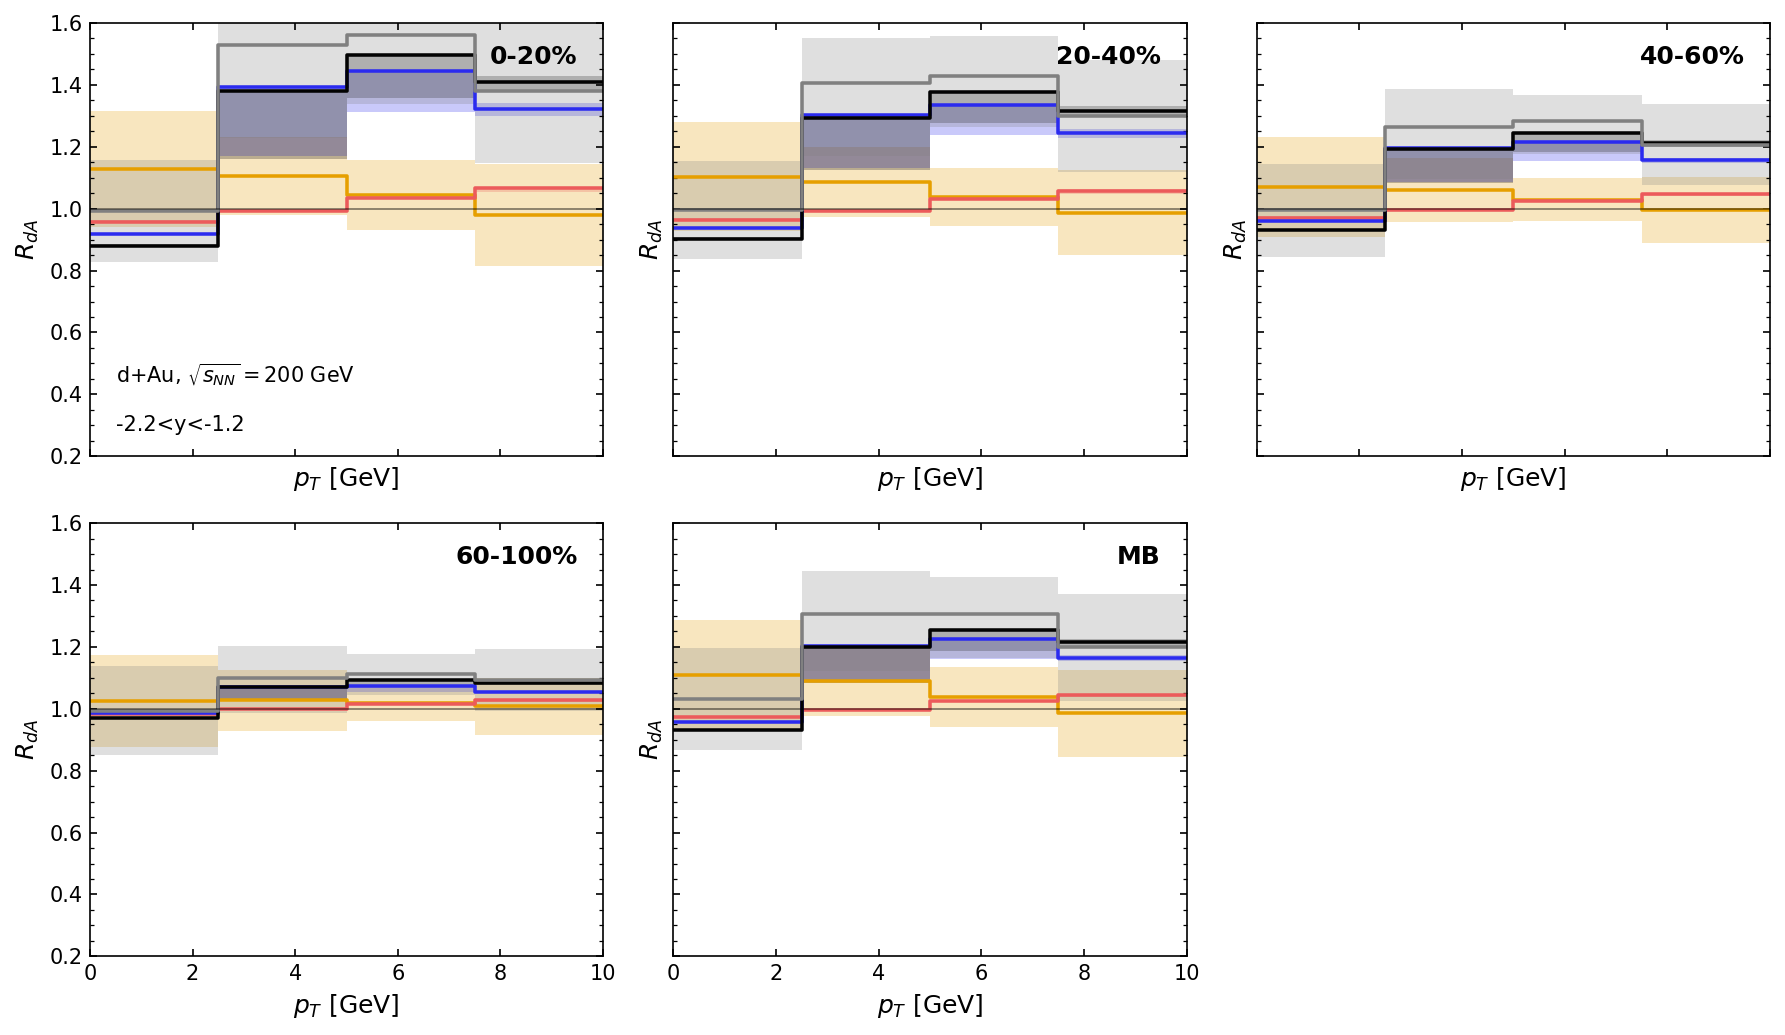

  Computing vs pT in window -0.35<y<0.35


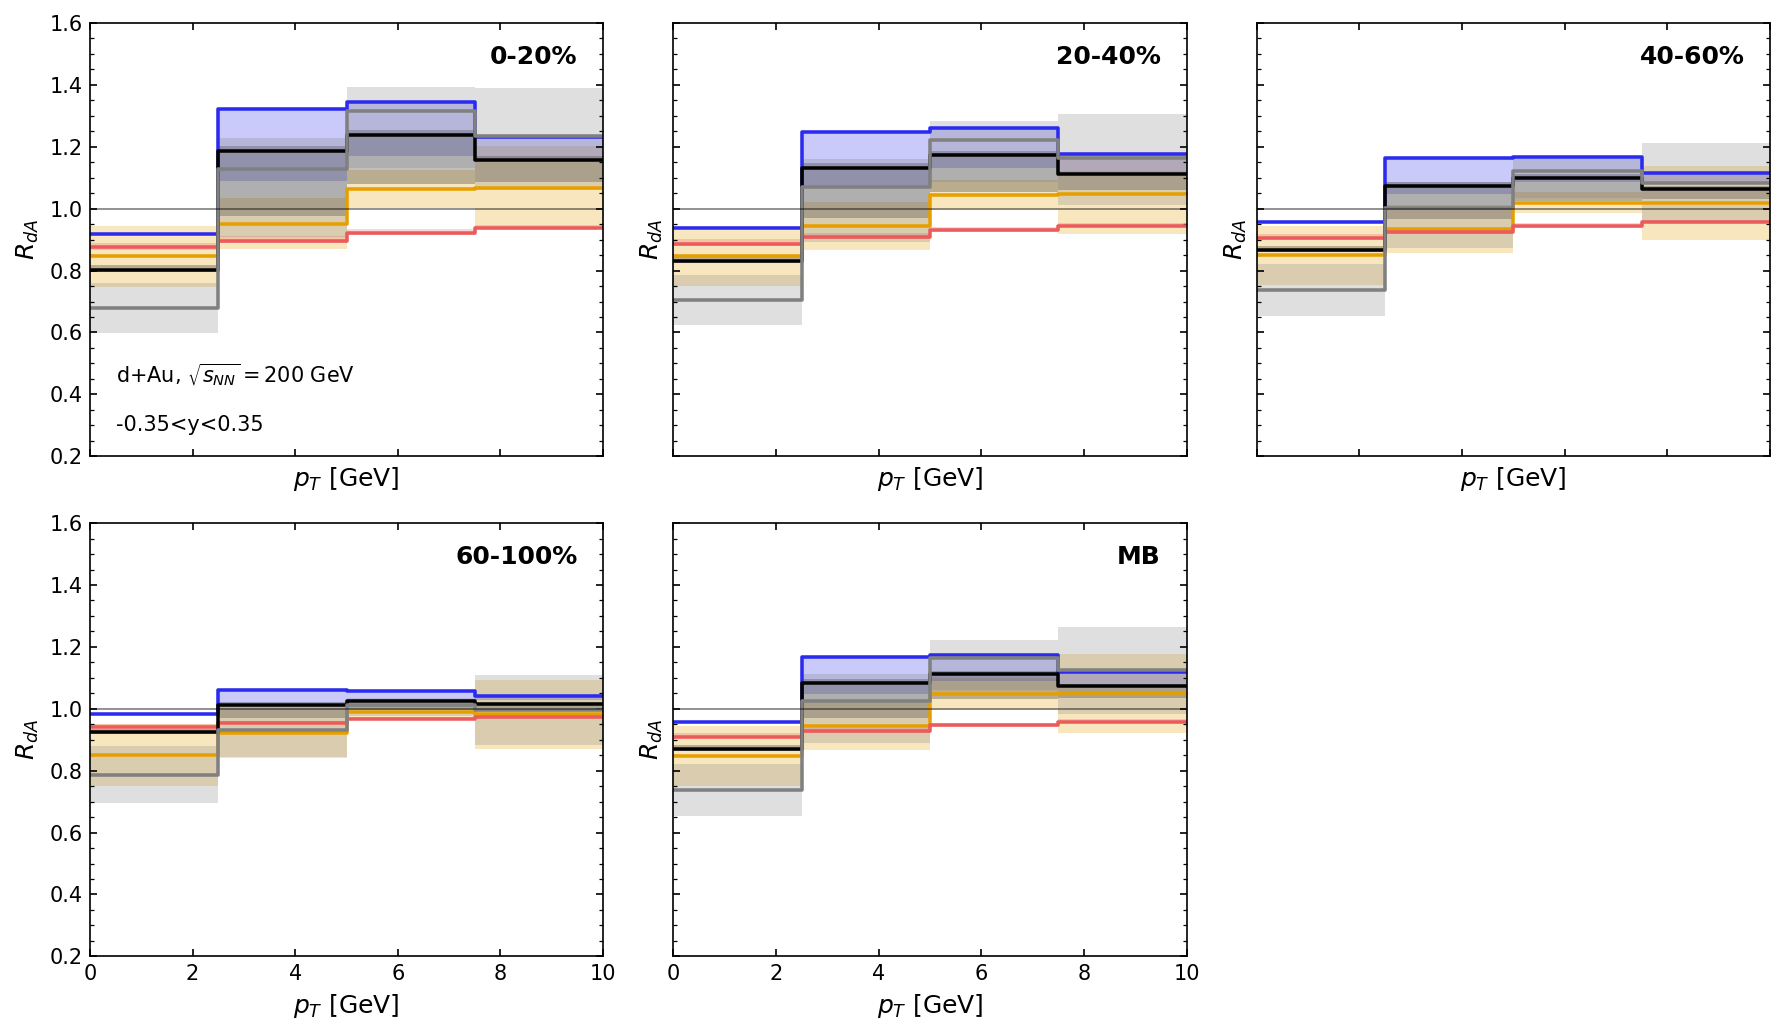

  Computing vs pT in window 1.2<y<2.2


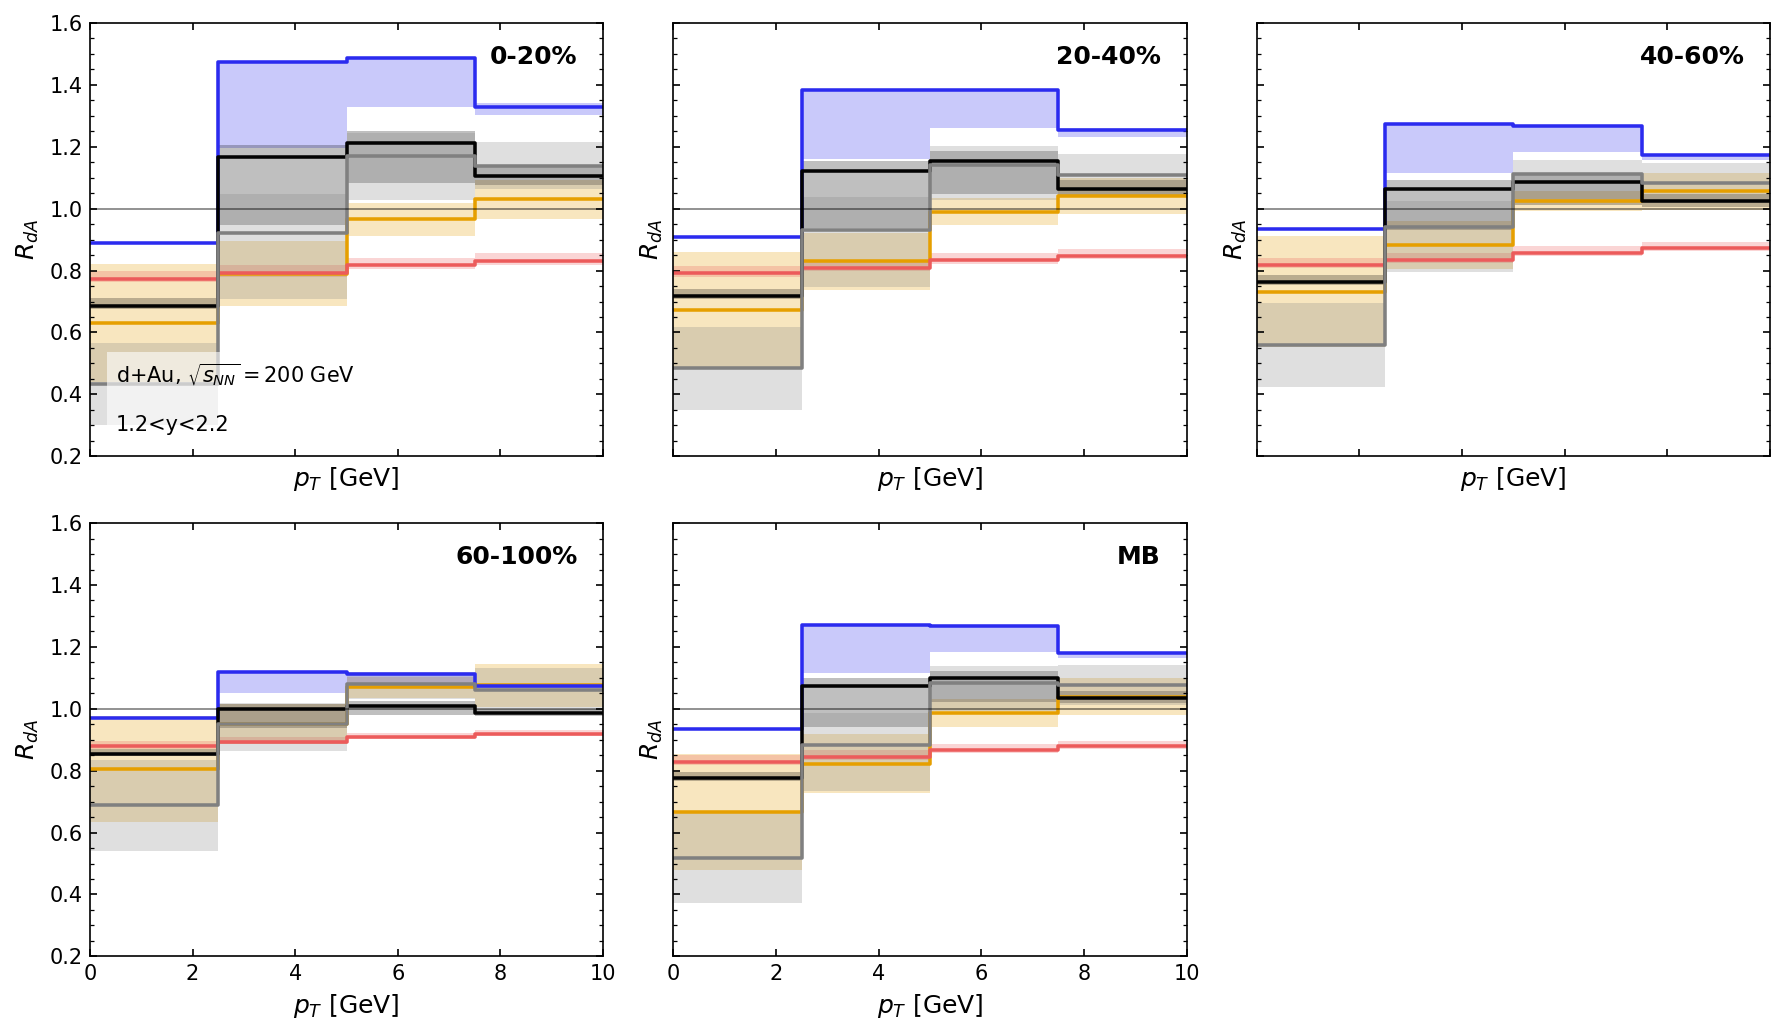

In [6]:
# 2. R_dA vs pT in Rapidity Windows
for y_window in Config.rapidity_windows:
    y0, y1 = y_window
    w_name = f"{y0}<y<{y1}"
    print(f"  Computing vs pT in window {w_name}")
    pT_edges = np.arange(0, 12.5, 2.5)
    pT_cent, labels_pt, final_bands_pt = cnm.cnm_vs_pT(y_window, pT_edges, components=components, include_mb=True)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), dpi=DPI, sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    note_pt = r"d+Au, $\sqrt{s_{NN}} = 200$ GeV" + "\n" + "\n"+ f"{w_name}"

    for i, tag in enumerate(tags_to_plot):
        ax = axes[i]
        for comp in components: plot_component_band(ax, pT_cent, final_bands_pt, comp, tag)
        apply_pub_style(ax, (0, 10), (0.2, 1.6), '$p_T$ [GeV]', r'$R_{dA}$', tag=tag, note=note_pt if i==0 else None)
        
    for k in range(n_pan, len(axes)): fig.delaxes(axes[k])
    fig.tight_layout()
    safe_w = w_name.replace('<','').replace('>','').replace('/','_')
    if SAVE_PDF: fig.savefig(outdir / f'RdAu_vs_pt_all_components_{safe_w}_200GeV.pdf', bbox_inches='tight')
    plt.show()

  Computing vs pT (MASTER GRID)...
  window -2.2<y<-1.2
  window -0.35<y<0.35
  window 1.2<y<2.2


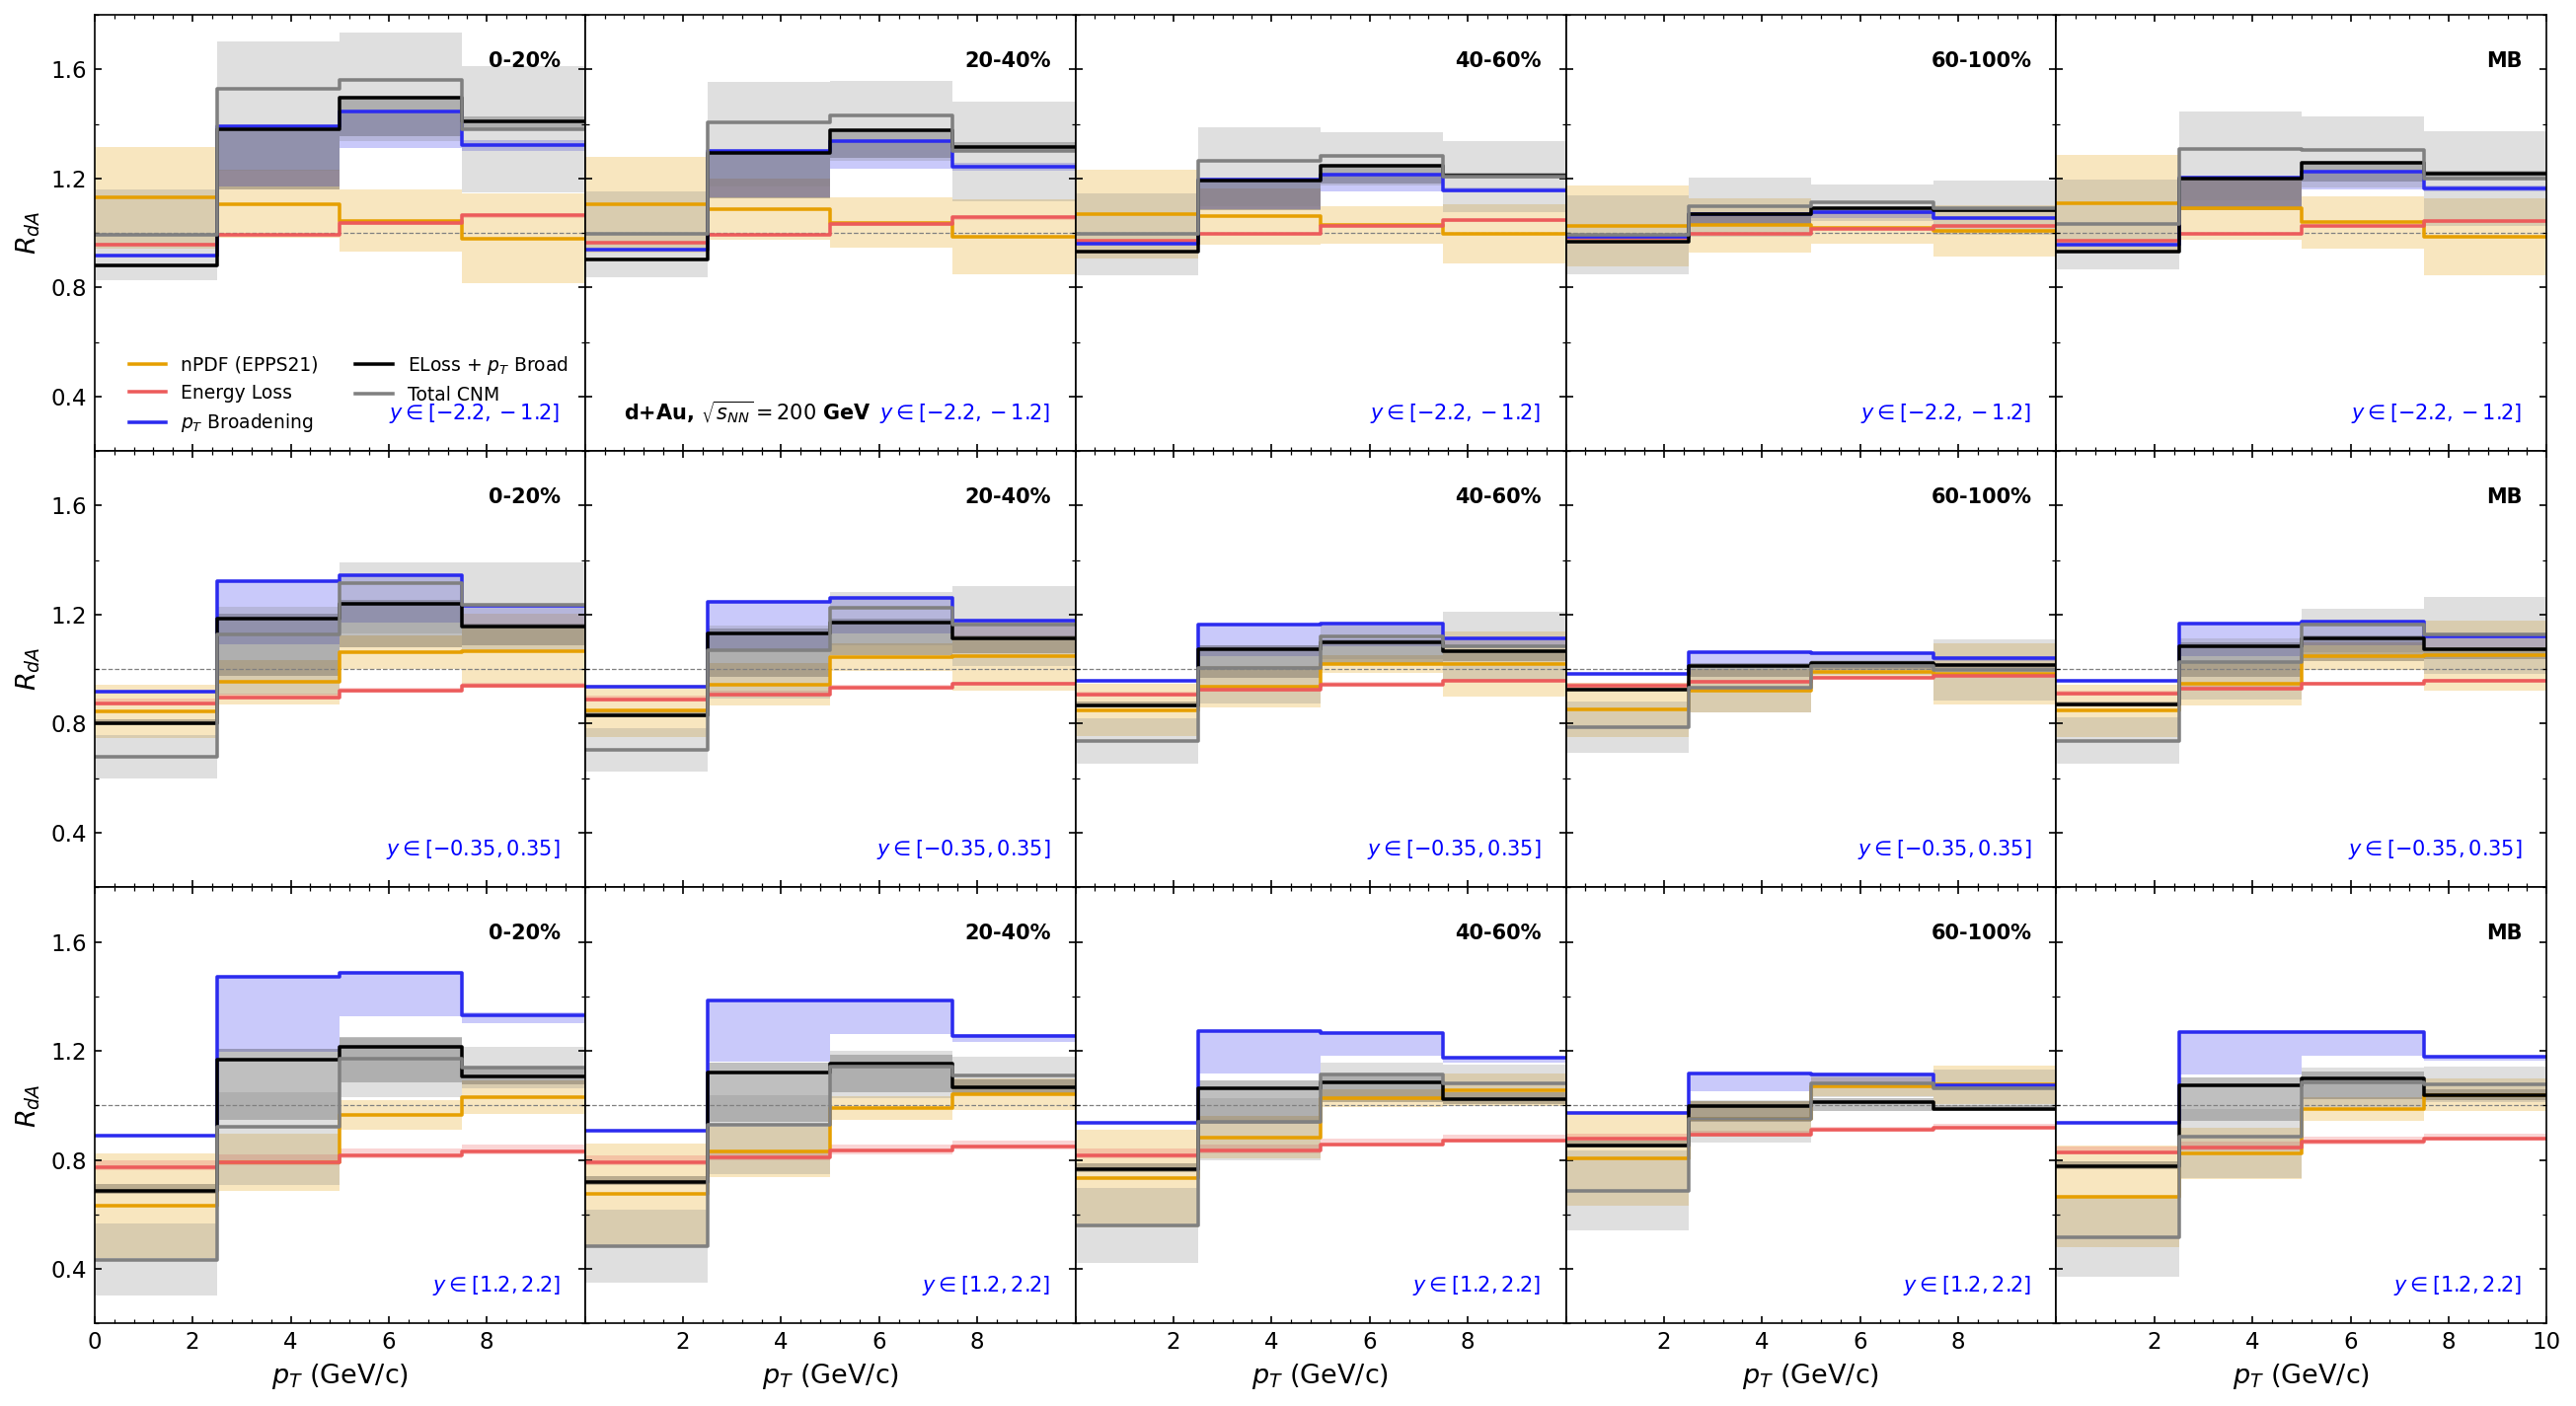

In [7]:
import matplotlib.ticker as ticker

print("  Computing vs pT (MASTER GRID)...")

y_windows = list(Config.rapidity_windows)
nrows = len(y_windows)

# compute first window once to know how many columns we need
y0, y1 = y_windows[0]
pT_edges = np.arange(0, 12.5, 2.5)
pT_cent0, labels_pt0, final_bands_pt0 = cnm.cnm_vs_pT((y0, y1), pT_edges, components=components, include_mb=True)

cent_tags = labels_pt0 + ["MB"]
ncols = len(cent_tags)

fig, axs = plt.subplots(
    nrows, ncols,
    figsize=(3.5*ncols, 3.2*nrows),
    dpi=DPI,
    sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.0, "hspace": 0.0}
)
axs = np.atleast_2d(axs)

# choose where to put the global system note: (row 0, col 1) if exists else (0,0)
note_row, note_col = 0, (1 if ncols > 1 else 0)

for irow, y_window in enumerate(y_windows):
    y0, y1 = y_window
    w_name = f"{y0}<y<{y1}"
    print(f"  window {w_name}")

    pT_edges = np.arange(0, 12.5, 2.5)
    pT_cent, labels_pt, final_bands_pt = cnm.cnm_vs_pT(
        y_window, pT_edges, components=components, include_mb=True
    )

    for jcol, tag in enumerate(cent_tags):
        ax = axs[irow, jcol]

        for comp in components:
            plot_component_band(ax, pT_cent, final_bands_pt, comp, tag, step=True)

        ax.axhline(1.0, color="gray", lw=0.6, ls="--", zorder=1)
        ax.set_xlim(0, 10)
        ax.set_ylim(0.2, 1.8)
        ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=11)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

        # ---- put y-window label on EVERY panel (bottom-right) ----
        ax.text(0.95, 0.06, rf"$y \in [{y0}, {y1}]$",
                transform=ax.transAxes, ha="right", va="bottom",
                fontsize=10, color="blue", fontweight="bold")

        # centrality tag at top-right (keep as you had)
        ax.text(0.95, 0.88, "MB" if tag == "MB" else tag,
                transform=ax.transAxes, ha="right", fontweight="bold", fontsize=10)

        if irow == nrows - 1:
            ax.set_xlabel(r"$p_T$ (GeV/c)", fontsize=13)
        if jcol == 0:
            ax.set_ylabel(r"$R_{dA}$", fontsize=13)

        # ---- global system note once, in a less-crowded panel ----
        if (irow == note_row) and (jcol == note_col):
            ax.text(0.08, 0.06, r"d+Au, $\sqrt{s_{NN}}=200$ GeV",
                    transform=ax.transAxes, ha="left", va="bottom",
                    fontsize=10, fontweight="bold")

        # ---- prevent x-axis label overlap between adjacent panels ----
        if irow == nrows - 1:
            ticks = ax.xaxis.get_major_ticks()
            if jcol > 0:
                ticks[0].label1.set_visible(False)
            if jcol < ncols - 1:
                ticks[-1].label1.set_visible(False)

axs[0, 0].legend(loc="lower right", fontsize=9, frameon=False, ncol=2)

fig.tight_layout()
if SAVE_PDF:
    fig.savefig(outdir / "RdAu_vs_pT_MASTERGRID_200GeV.pdf", bbox_inches="tight")
plt.show()

## 3. $R_{dA}$ vs Centrality

  Computing vs Centrality...


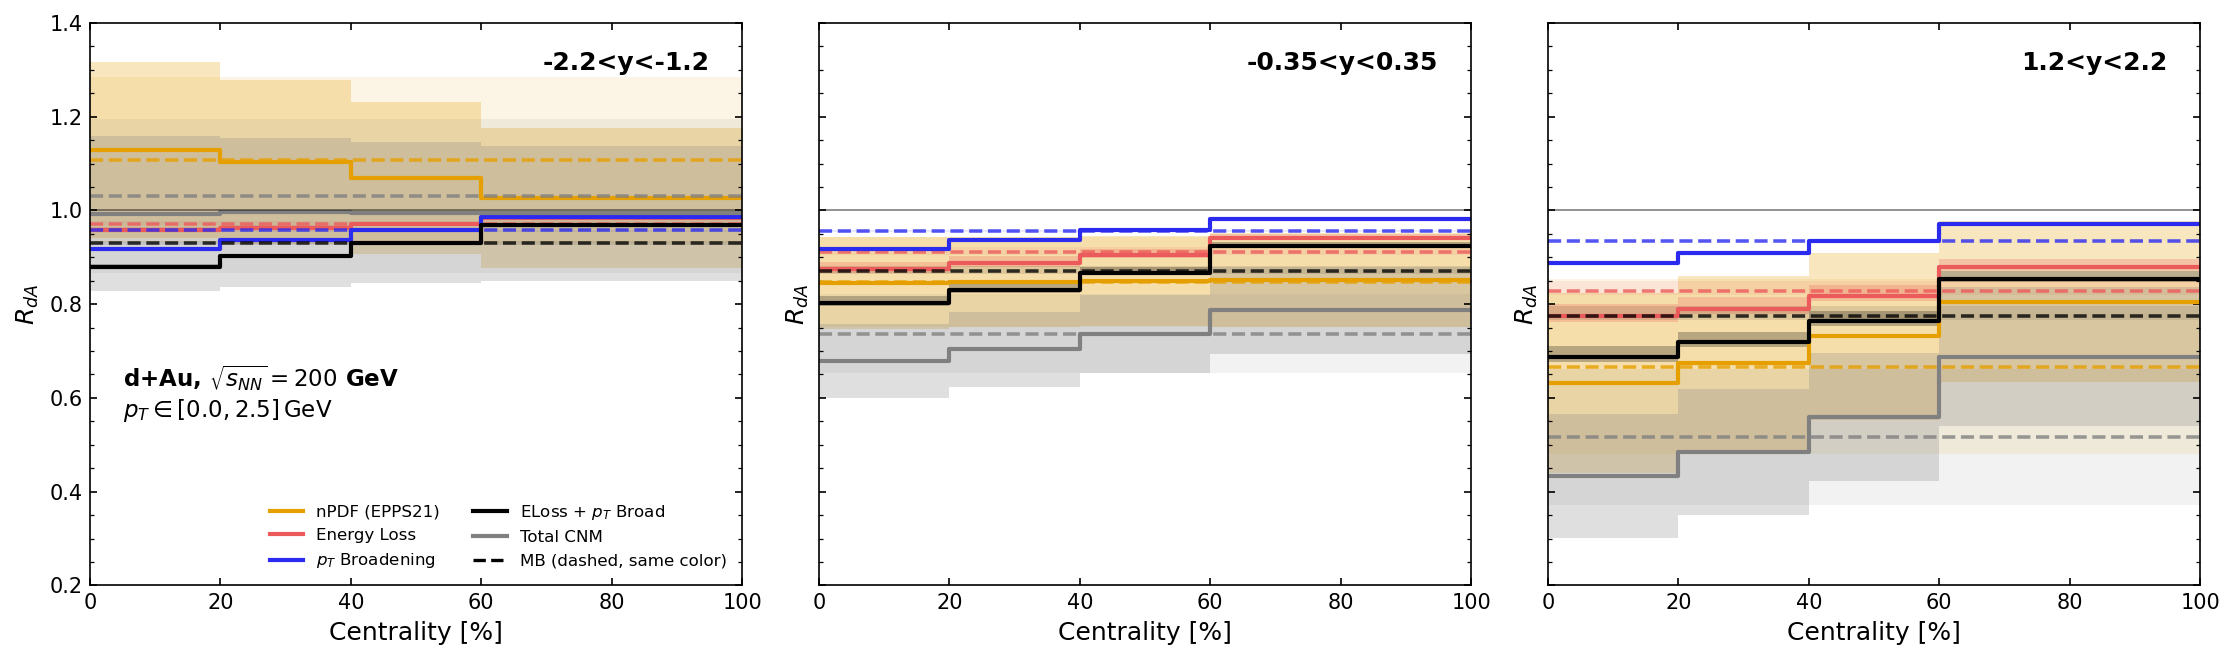

In [8]:
# 3. R_dA vs Centrality (STEP PLOT)
print("  Computing vs Centrality...")
from matplotlib.lines import Line2D

cent_bins = Config.cent_bins
x_edges = np.array([cent_bins[0][0]] + [b for (_, b) in cent_bins], dtype=float)

def cent_step(yvals):
    yvals = np.asarray(yvals, float)
    return np.r_[yvals, yvals[-1]]

pt_min, pt_max = (0.0, 2.5)

# one legend handle that explains the rule (dashed line = MB, same color as component)
mb_handle = Line2D([0], [0], color="k", lw=1.6, ls="--", label="MB (dashed, same color)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=DPI, sharey=True)

for ax, y_window in zip(axes, Config.rapidity_windows):
    y0, y1 = y_window
    res_cent = cnm.cnm_vs_centrality((y0, y1), pt_range_avg=(pt_min, pt_max))

    for comp in components:
        vc, vl, vh, mbc, mbl, mbh = res_cent[comp]
        color = COLORS[comp]
        label = COMP_LABELS[comp]

        y_c  = cent_step(vc)
        y_lo = cent_step(vl)
        y_hi = cent_step(vh)

        ax.step(x_edges, y_c, where="post", color=color, lw=2.0,
                label=label if ax==axes[0] else None)
        ax.fill_between(x_edges, y_lo, y_hi, step="post",
                        color=color, alpha=ALPHA_BAND, lw=0)

        # MB (same color as component)
        ax.hlines(mbc, 0.0, 100.0, colors=color, linestyles="--", linewidth=1.7, alpha=0.8)
        ax.fill_between([0.0, 100.0], [mbl, mbl], [mbh, mbh],
                        color=color, alpha=0.1, lw=0)

    apply_pub_style(ax, (0, 100), (0.2, 1.4), 'Centrality [%]', r'$R_{dA}$',
                    tag=f"{y0}<y<{y1}")

    if ax == axes[0]:
        handles, lab = ax.get_legend_handles_labels()
        handles.append(mb_handle)
        ax.legend(handles=handles, labels=lab + [mb_handle.get_label()],
                  loc='lower right', fontsize=8, frameon=False, ncol=2)

        ax.text(0.05, 0.30,
                r"d+Au, $\sqrt{s_{NN}}=200$ GeV"
                "\n"
                rf"$p_T \in [{pt_min}, {pt_max}]\,\mathrm{{GeV}}$",
                transform=ax.transAxes, fontsize=11, fontweight='bold')

fig.tight_layout()
if SAVE_PDF:
    fig.savefig(outdir / 'RdAu_vs_centrality_all_components_200GeV.pdf', bbox_inches='tight')
plt.show()

  Computing vs Centrality...


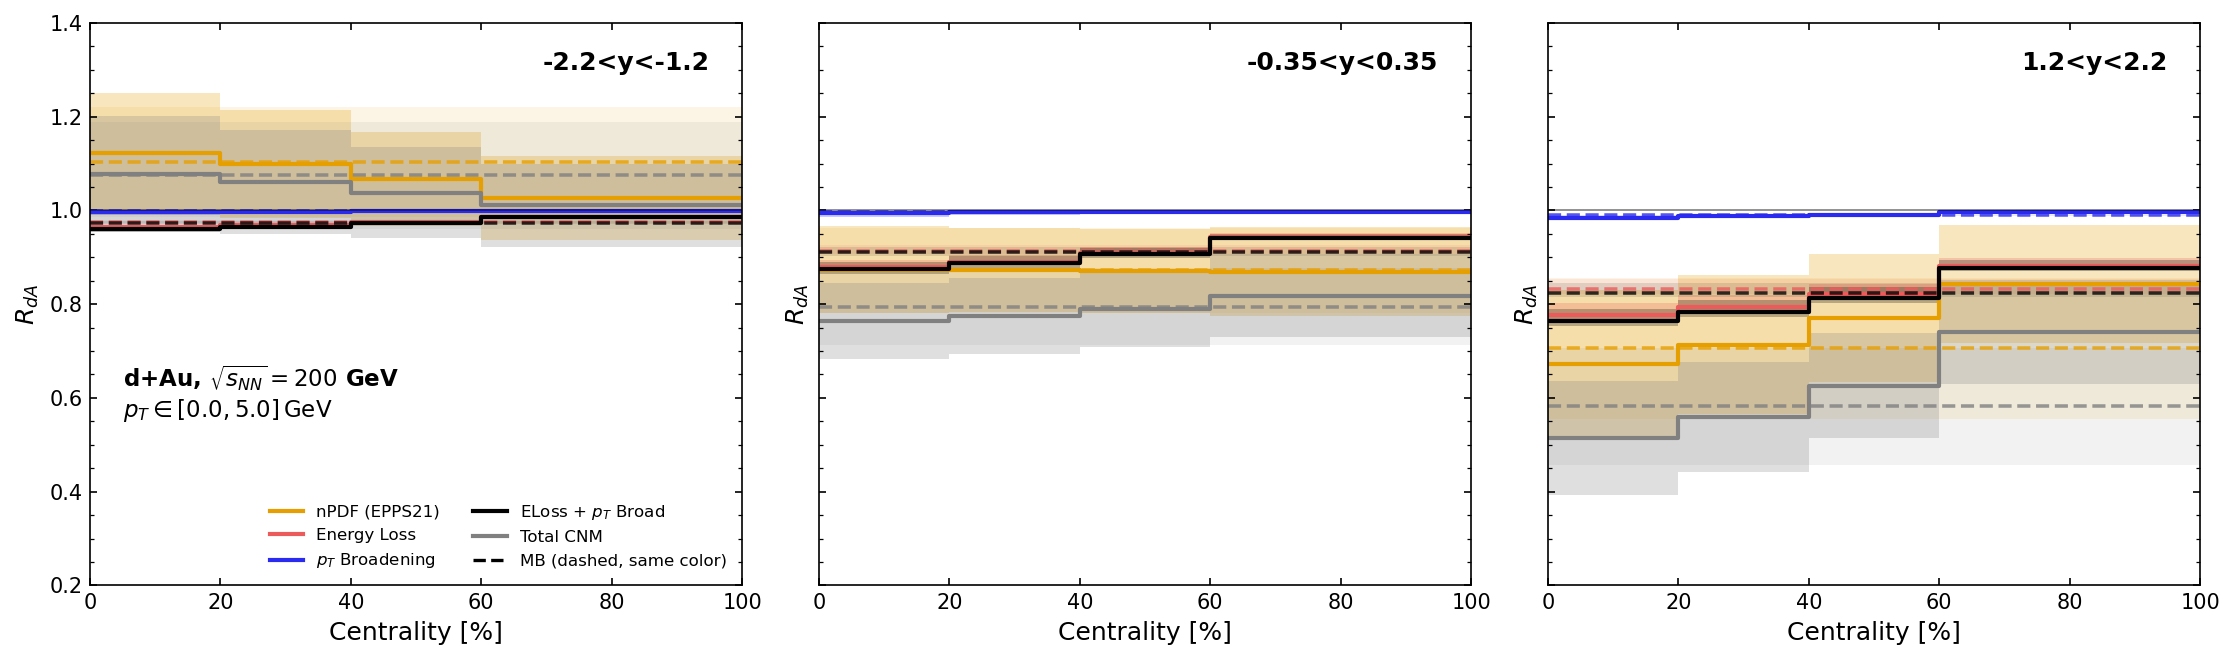

In [9]:
# 3. R_dA vs Centrality (STEP PLOT)
print("  Computing vs Centrality...")
from matplotlib.lines import Line2D

cent_bins = Config.cent_bins
x_edges = np.array([cent_bins[0][0]] + [b for (_, b) in cent_bins], dtype=float)

def cent_step(yvals):
    yvals = np.asarray(yvals, float)
    return np.r_[yvals, yvals[-1]]

pt_min, pt_max = (0.0, 5.0)

# one legend handle that explains the rule (dashed line = MB, same color as component)
mb_handle = Line2D([0], [0], color="k", lw=1.6, ls="--", label="MB (dashed, same color)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=DPI, sharey=True)

for ax, y_window in zip(axes, Config.rapidity_windows):
    y0, y1 = y_window
    res_cent = cnm.cnm_vs_centrality((y0, y1), pt_range_avg=(pt_min, pt_max))

    for comp in components:
        vc, vl, vh, mbc, mbl, mbh = res_cent[comp]
        color = COLORS[comp]
        label = COMP_LABELS[comp]

        y_c  = cent_step(vc)
        y_lo = cent_step(vl)
        y_hi = cent_step(vh)

        ax.step(x_edges, y_c, where="post", color=color, lw=2.0,
                label=label if ax==axes[0] else None)
        ax.fill_between(x_edges, y_lo, y_hi, step="post",
                        color=color, alpha=ALPHA_BAND, lw=0)

        # MB (same color as component)
        ax.hlines(mbc, 0.0, 100.0, colors=color, linestyles="--", linewidth=1.7, alpha=0.8)
        ax.fill_between([0.0, 100.0], [mbl, mbl], [mbh, mbh],
                        color=color, alpha=0.1, lw=0)

    apply_pub_style(ax, (0, 100), (0.2, 1.4), 'Centrality [%]', r'$R_{dA}$',
                    tag=f"{y0}<y<{y1}")

    if ax == axes[0]:
        handles, lab = ax.get_legend_handles_labels()
        handles.append(mb_handle)
        ax.legend(handles=handles, labels=lab + [mb_handle.get_label()],
                  loc='lower right', fontsize=8, frameon=False, ncol=2)

        ax.text(0.05, 0.30,
                r"d+Au, $\sqrt{s_{NN}}=200$ GeV"
                "\n"
                rf"$p_T \in [{pt_min}, {pt_max}]\,\mathrm{{GeV}}$",
                transform=ax.transAxes, fontsize=11, fontweight='bold')

fig.tight_layout()
if SAVE_PDF:
    fig.savefig(outdir / 'RdAu_vs_centrality_all_components_200GeV_wider.pdf', bbox_inches='tight')
plt.show()